# FracAtlas hyperparameter tuning and final model selection

This notebook tunes all three architectures using the same reproducible split, selects the best trial for each, compares them by class-average recall, evaluates the winner on the untouched test set, and saves the final model for FastAPI.

In [8]:
from pathlib import Path
import itertools, json, math, sys, gc

SERVICE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(SERVICE_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from app.config import ARTIFACT_DIR, IMAGE_SIZE, SEED
from app.data import load_manifest, split_manifest, undersample_majority
from app.labels import CLASS_NAMES
from app.metrics import SELECTION_METRIC
from app.model import MODEL_NAMES, build_model, build_transfer_model

tf.keras.utils.set_random_seed(SEED)
EPOCHS = 5
MAX_TRIALS_PER_MODEL = 2
MODEL_DIR = ARTIFACT_DIR / 'tuning'
MODEL_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
manifest = load_manifest()
train, validation, test = split_manifest(manifest)
print(f'Images: {len(manifest):,} | train: {len(train):,} | validation: {len(validation):,} | test: {len(test):,}')

def make_dataset(frame, batch_size, shuffle=False):
    paths = frame['path'].to_numpy()
    labels = frame['label_index'].to_numpy(dtype=np.int32)
    def load(path, label):
        image = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
        return tf.image.resize(image, IMAGE_SIZE), label
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    return dataset.map(load, num_parallel_calls=1).apply(tf.data.experimental.ignore_errors()).batch(batch_size).prefetch(1)

def calculate_metrics(actual, predicted):
    labels = np.arange(len(CLASS_NAMES))
    class_precision, class_recall, class_f1, _ = precision_recall_fscore_support(
        actual, predicted, labels=labels, average=None, zero_division=0)
    return {
        'accuracy': float(accuracy_score(actual, predicted)),
        'average_precision': float(np.mean(class_precision)),
        'average_recall': float(np.mean(class_recall)),
        'average_f1': float(np.mean(class_f1)),
    }

def is_better(candidate, current):
    keys = ('average_recall', 'average_f1', 'average_precision', 'accuracy')
    return current is None or tuple(candidate[key] for key in keys) > tuple(current[key] for key in keys)


W0000 00:00:1788043693.102308     374 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1788043693.103910     374 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1788043693.348564     374 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a
E0000 00:00:1788043730.952864     374 jpeg_mem.cc:331] Premature end of JPEG data. Stopped at line 414/454
W0000 00:00:1788043730.952923     374 local_rendezvous.cc:412] Local rendezvous is aborting with status: INVALID_ARGUMENT: jpeg::Uncompress failed. Invalid JPEG data or crop win

Images: 4,024 | train: 3,219 | validation: 402 | test: 403


In [3]:
search_space = list(itertools.product((1e-3, 3e-4), (16, 32), (False, True)))
if MAX_TRIALS_PER_MODEL > 0:
    search_space = search_space[:MAX_TRIALS_PER_MODEL]

all_results, best_by_model = [], {}

for model_name in MODEL_NAMES:
    best = None
    best_path = MODEL_DIR / f'{model_name}_best.keras'
    for trial, (learning_rate, batch_size, undersample) in enumerate(search_space, start=1):
        print(f'===== Training {model_name} trial {trial}/{len(search_space)} =====', flush=True)
        tf.keras.backend.clear_session()
        trial_train = undersample_majority(train) if undersample else train
        weights = compute_class_weight(class_weight='balanced', classes=np.arange(len(CLASS_NAMES)), y=trial_train['label_index'].to_numpy())
        class_weights = {index: float(value) for index, value in enumerate(weights)}
        model = build_model(learning_rate=learning_rate) if model_name == 'custom_cnn' else build_transfer_model(model_name, learning_rate=learning_rate)
        model.fit(
            make_dataset(trial_train, batch_size, True).repeat(),
            validation_data=make_dataset(validation, batch_size, False).repeat(),
            epochs=EPOCHS,
            steps_per_epoch=math.ceil(len(trial_train) / batch_size),
            validation_steps=math.ceil(len(validation) / batch_size),
            class_weight=class_weights,
            callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
            verbose=1,
        )
        probabilities = model.predict(make_dataset(validation, batch_size, False), verbose=0)
        row = {
            'model': model_name, 'trial': trial, 'learning_rate': learning_rate,
            'batch_size': batch_size, 'undersample_majority': undersample,
            'effective_train_count': len(trial_train),
            **calculate_metrics(validation['label_index'].to_numpy(), np.argmax(probabilities, axis=1)),
        }
        all_results.append(row)
        if is_better(row, best):
            best = row
            model.save(best_path)
        print(json.dumps(row, indent=2), flush=True)
        del model
        gc.collect()
        tf.keras.backend.clear_session()
    best['model_path'] = str(best_path)
    best_by_model[model_name] = best
    print('Best', model_name, best)


===== Training custom_cnn trial 1/2 =====
Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.
Epoch 1/5


/home/rushd/fracturecare-ai-venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
E0000 00:00:1788043736.044557     374 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/fracatlas_fracture_classifier_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1788043736.879553     409 cuda_dnn.cc:461] Loaded cuDNN version 92400


202/202 ━━━━━━━━━━━━━━━━━━━━ 37s 154ms/step - accuracy: 0.4281 - loss: 1.1041 - val_accuracy: 0.8234 - val_loss: 0.7831
Epoch 2/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 30s 151ms/step - accuracy: 0.5163 - loss: 1.0469 - val_accuracy: 0.8234 - val_loss: 0.7310
Epoch 3/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 29s 142ms/step - accuracy: 0.5505 - loss: 1.0070 - val_accuracy: 0.2687 - val_loss: 1.3036
Epoch 4/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 41s 204ms/step - accuracy: 0.5794 - loss: 0.9861 - val_accuracy: 0.1841 - val_loss: 1.1874
{
  "model": "custom_cnn",
  "trial": 1,
  "learning_rate": 0.001,
  "batch_size": 16,
  "undersample_majority": false,
  "effective_train_count": 3219,
  "accuracy": 0.8233830845771144,
  "average_precision": 0.27446102819237145,
  "average_recall": 0.3333333333333333,
  "average_f1": 0.3010459299681673
}


/home/rushd/fracturecare-ai-venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


===== Training custom_cnn trial 2/2 =====
Epoch 1/5


...

{
  "model": "efficientnetb0",
  "trial": 1,
  "learning_rate": 0.001,
  "batch_size": 16,
  "undersample_majority": false,
  "effective_train_count": 3219,
  "accuracy": 0.8208955223880597,
  "average_precision": 0.611672278338945,
  "average_recall": 0.6216500251213835,
  "average_f1": 0.6165048414165912
}
===== Training efficientnetb0 trial 2/2 =====
Epoch 1/5


/home/rushd/fracturecare-ai-venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


113/113 ━━━━━━━━━━━━━━━━━━━━ 27s 189ms/step - accuracy: 0.5728 - loss: 0.9449 - val_accuracy: 0.7761 - val_loss: 0.5002
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 19s 171ms/step - accuracy: 0.6774 - loss: 0.7701 - val_accuracy: 0.7612 - val_loss: 0.5388
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 20s 176ms/step - accuracy: 0.7023 - loss: 0.7239 - val_accuracy: 0.7811 - val_loss: 0.5991
{
  "model": "efficientnetb0",
  "trial": 2,
  "learning_rate": 0.001,
  "batch_size": 16,
  "undersample_majority": true,
  "effective_train_count": 1807,
  "accuracy": 0.7761194029850746,
  "average_precision": 0.6050326045262754,
  "average_recall": 0.5528865456891047,
  "average_f1": 0.567826462025089
}


/home/rushd/fracturecare-ai-venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Best efficientnetb0 {'model': 'efficientnetb0', 'trial': 1, 'learning_rate': 0.001, 'batch_size': 16, 'undersample_majority': False, 'effective_train_count': 3219, 'accuracy': 0.8208955223880597, 'average_precision': 0.611672278338945, 'average_recall': 0.6216500251213835, 'average_f1': 0.6165048414165912, 'model_path': '/mnt/c/Users/Rushd/OneDrive - wslqd/Documents/Uni Documents/ICBT/Development Project Final Year/Final Documents/fracturecare-prototype/ai-service/artifacts/tuning/efficientnetb0_best.keras'}


,model,learning_rate,batch_size,undersample_majority,accuracy,average_precision,average_recall,average_f1
0,efficientnetb0,0.001,16,False,0.820896,0.611672,0.621650,0.616505
1,mobilenetv2,0.001,16,True,0.773632,0.609222,0.535341,0.545163
2,custom_cnn,0.001,16,False,0.823383,0.274461,0.333333,0.301046


Selected architecture: efficientnetb0
Test metrics: {
  "accuracy": 0.8411910669975186,
  "average_precision": 0.6469958126399845,
  "average_recall": 0.638362656240744,
  "average_f1": 0.6403776020753634
}
Confusion matrix: [[299, 26, 6], [21, 33, 1], [6, 4, 7]]


/home/rushd/fracturecare-ai-venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


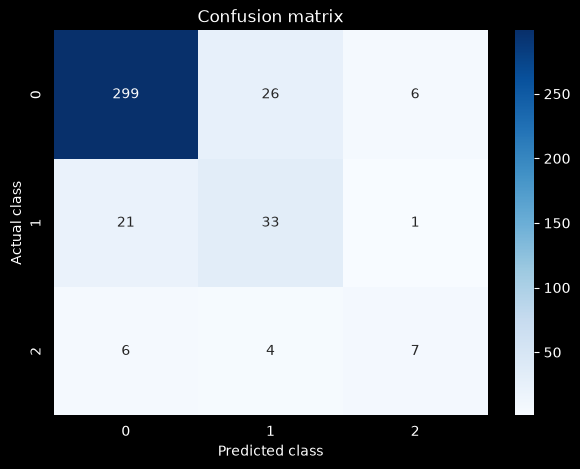

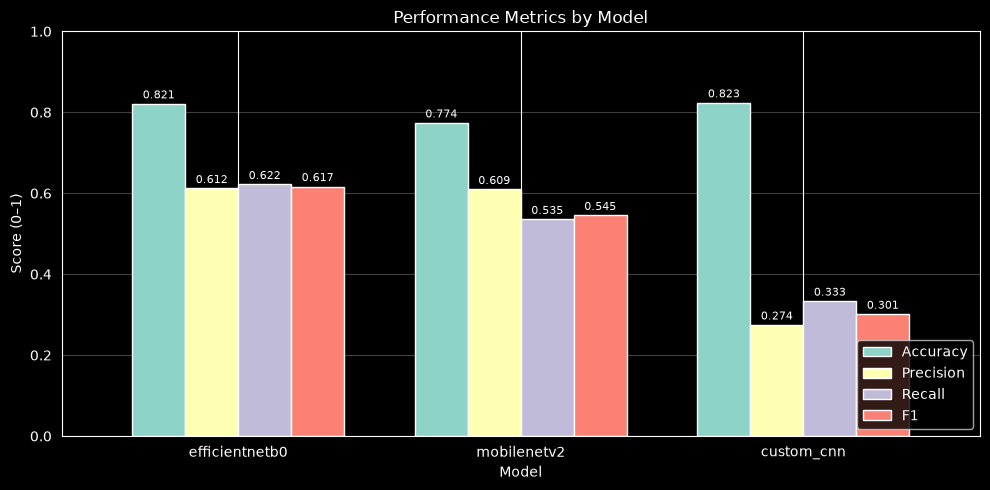

In [11]:
results_frame = pd.DataFrame(all_results).sort_values(
    ['average_recall', 'average_f1', 'average_precision', 'accuracy'], ascending=False).reset_index(drop=True)
best_frame = pd.DataFrame(best_by_model.values()).sort_values(
    ['average_recall', 'average_f1', 'average_precision', 'accuracy'], ascending=False).reset_index(drop=True)
display(best_frame[['model', 'learning_rate', 'batch_size', 'undersample_majority',
                    'accuracy', 'average_precision', 'average_recall', 'average_f1']])
best = best_frame.iloc[0].to_dict()
selected_model = tf.keras.models.load_model(best['model_path'], compile=False)
test_probabilities = selected_model.predict(make_dataset(test, int(best['batch_size']), False), verbose=0)
test_actual = test['label_index'].to_numpy()
test_predicted = np.argmax(test_probabilities, axis=1)
final_test_metrics = calculate_metrics(test_actual, test_predicted)
print('Selected architecture:', best['model'])
print('Test metrics:', json.dumps(final_test_metrics, indent=2))
print('Confusion matrix:', confusion_matrix(test_actual, test_predicted, labels=np.arange(len(CLASS_NAMES))).tolist())


plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(test_actual, test_predicted, labels=np.arange(len(CLASS_NAMES))), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.title('Confusion matrix')
plt.show()


#Metric comparison for each model
plot_data = best_frame.set_index('model')[
    ['accuracy', 'average_precision', 'average_recall', 'average_f1']
]

ax = plot_data.plot(
    kind='bar',
    figsize=(10, 5),
    ylim=(0, 1),
    width=0.75
)

ax.set_title('Performance Metrics by Model')
ax.set_xlabel('Model')
ax.set_ylabel('Score (0–1)')
ax.legend(
    ['Accuracy', 'Precision', 'Recall', 'F1'],
    loc='lower right'
)
ax.grid(axis='y', alpha=0.25)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=2,
        fontsize=8
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [7]:
final_model_path = ARTIFACT_DIR / 'fracture_classifier.keras'
selected_model.save(final_model_path)
best_frame.to_csv(ARTIFACT_DIR / 'tuned_model_comparison.csv', index=False)

def report_rows(frame, variant, source):
    if frame.empty:
        return pd.DataFrame()
    return frame.assign(evaluation_set='validation', training_variant=variant, source=source)[
        ['evaluation_set', 'training_variant', 'model', 'accuracy',
         'average_precision', 'average_recall', 'average_f1', 'source']]

untuned_path = ARTIFACT_DIR / 'model_comparison.csv'
untuned_frame = pd.read_csv(untuned_path) if untuned_path.exists() else pd.DataFrame()
final_row = pd.DataFrame([{'evaluation_set': 'test', 'training_variant': 'tuned',
    'model': best['model'], **final_test_metrics,
    'source': 'model_metadata.json finalTestMetrics'}])
canonical = pd.concat([
    report_rows(untuned_frame, 'untuned', 'model_comparison.csv'),
    report_rows(best_frame, 'tuned', 'tuned_model_comparison.csv'),
    final_row,
], ignore_index=True)
canonical.to_csv(ARTIFACT_DIR / 'FINAL_MODEL_METRICS.csv', index=False)
metadata = {
    'modelVersion': f'fracatlas-{best["model"]}-tuned-1.0.0',
    'selectedModel': best['model'], 'architecture': best['model'],
    'classes': list(CLASS_NAMES), 'imageSize': list(IMAGE_SIZE),
    'dataset': 'FracAtlas', 'trainCount': int(len(train)),
    'validationCount': int(len(validation)), 'testCount': int(len(test)),
    'selectionMetric': SELECTION_METRIC,
    'selectedHyperparameters': {key: best[key] for key in ('learning_rate', 'batch_size', 'undersample_majority', 'effective_train_count')},
    'comparison': best_frame.to_dict(orient='records'),
    'finalTestMetrics': final_test_metrics,
    'confusionMatrix': confusion_matrix(test_actual, test_predicted, labels=np.arange(len(CLASS_NAMES))).tolist(),
}
(ARTIFACT_DIR / 'model_metadata.json').write_text(json.dumps(metadata, indent=2, default=float), encoding='utf-8')
print('Saved final model for FastAPI:', final_model_path)


Saved final model for FastAPI: /mnt/c/Users/Rushd/OneDrive - wslqd/Documents/Uni Documents/ICBT/Development Project Final Year/Final Documents/fracturecare-prototype/ai-service/artifacts/fracture_classifier.keras
